In [9]:
import numpy as np
import pandas as pd
import os
from scipy.io import loadmat, savemat
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load mean waveforms and cluster IDs from matlab
matlab_path = r"\\fsmresfiles.fsm.northwestern.edu\fsmresfiles\Basic_Sciences\Phys\SenzaiLab\Aparna\Mouse08\mean-waveforms-good-clusters"
mat_file = os.path.join(matlab_path, "meanWav_units.mat")

ksDir = r"D:\Kilosort\Mouse08_SC_20251007_810to2250\kilosort4"
chan_pos_file = os.path.join(ksDir, 'channel_positions.npy')

data = loadmat(mat_file)
meanWav = data['meanWav']          # nChannels x nSamples x nUnits
good_clusters = data['good_clusters'].squeeze()  # 1D array of cluster IDs

chan_pos = np.load(chan_pos_file)
xpos = chan_pos[:, 0]
ypos = chan_pos[:, 1]

nCh, nS, nUnits = meanWav.shape
num_channels_to_plot = 21  # number of channels around peak to include
spatialWindow = 300 # micrometers

sr = 30000  # Sampling rate in Hz (from your MATLAB script)
sbefore = 30  # Samples before trough (from your MATLAB script)
safter = 60   # Samples after trough (from your MATLAB script)



In [2]:
# function to extract multi-channel waveforms and spatial features per unit

def get_multichannel_waveform_features(unit_idx, meanWav, xpos, ypos, num_channels=21, spatial_window=300):
    """
    Extract waveform features including spatial spread.
    
    Key differences:
    - RGC axons: LARGE spatial spread, fast bi/triphasic + slow trough
    - SC neurons: SMALL spatial spread, biphasic somatic action potential
    """
    mean_wave = meanWav[:, :, unit_idx]
    
    # Find peak channel (max absolute amplitude)
    peak_ch = np.argmax(np.max(np.abs(mean_wave), axis=1))
    peak_waveform = mean_wave[peak_ch, :]
    
    peak_x = xpos[peak_ch]
    peak_y = ypos[peak_ch]
    
    # Get same-shank, same-parity channels
    sameshank = np.where(xpos == peak_x)[0]
    peak_parity = peak_ch % 2
    same_parity = sameshank[sameshank % 2 == peak_parity]
    
    # Get spatial neighbors
    y_distance = np.abs(ypos[same_parity] - peak_y)
    nearby_idx = np.where(y_distance <= spatial_window)[0]
    channels_to_use = same_parity[nearby_idx]
    
    # If too few, expand to nearest neighbors
    if len(channels_to_use) < num_channels:
        sorted_idx = np.argsort(y_distance)
        n_take = min(num_channels, len(same_parity))
        channels_to_use = same_parity[sorted_idx[:n_take]]
    
    # If too many, keep closest
    if len(channels_to_use) > num_channels:
        distances = np.abs(ypos[channels_to_use] - peak_y)
        sorted_idx = np.argsort(distances)
        channels_to_use = channels_to_use[sorted_idx[:num_channels]]
    
    # Get multi-channel waveforms sorted by depth
    depth_order = np.argsort(ypos[channels_to_use])[::-1]  # superficial to deep
    sorted_channels = channels_to_use[depth_order]
    multichan_waveforms = mean_wave[sorted_channels, :]
    
    return {
        'peak_waveform': peak_waveform,
        'peak_ch': peak_ch,
        'channels': sorted_channels,
        'multichan_waveforms': multichan_waveforms,
        'channel_depths': ypos[sorted_channels],
        'peak_depth': peak_y
    }


In [3]:
# Extract multi-channel waveform features for all units
unit_data = []
for i in tqdm(range(nUnits), desc="Extracting multi-channel waveforms"):
    data = get_multichannel_waveform_features(i, meanWav, xpos, ypos)
    unit_data.append(data)

Extracting multi-channel waveforms:   0%|          | 0/130 [00:00<?, ?it/s]

In [4]:
# EXTRACT SPATIAL SPREAD FEATURES

def calculate_spatial_spread(multichan_waveforms, channel_depths, peak_depth):
    """
    Calculate spatial spread of the waveform.
    
    RGC axons: Large spatial spread (activity on many channels)
    SC neurons: Small spatial spread (localized to soma)
    """
    features = {}
    
    # 1. Amplitude-based spread: Find channels with significant activity
    # Define "significant" as >20% of peak channel amplitude
    peak_amp = np.max(np.abs(multichan_waveforms[len(multichan_waveforms)//2, :]))  # middle channel (likely peak)
    threshold = 0.2 * peak_amp
    
    max_amps_per_channel = np.max(np.abs(multichan_waveforms), axis=1)
    active_channels = max_amps_per_channel > threshold
    
    features['n_active_channels'] = np.sum(active_channels)
    
    # 2. Spatial extent in micrometers
    if np.sum(active_channels) > 1:
        active_depths = channel_depths[active_channels]
        spatial_extent = np.max(active_depths) - np.min(active_depths)
        features['spatial_extent_um'] = spatial_extent
    else:
        features['spatial_extent_um'] = 0
    
    # 3. Weighted spatial spread (amplitude-weighted)
    weights = max_amps_per_channel / np.sum(max_amps_per_channel)
    weighted_depth = np.sum(weights * channel_depths)
    weighted_variance = np.sum(weights * (channel_depths - weighted_depth)**2)
    features['spatial_spread_weighted'] = np.sqrt(weighted_variance)
    
    # 4. Half-max spatial spread
    half_max = 0.5 * peak_amp
    half_max_channels = max_amps_per_channel > half_max
    if np.sum(half_max_channels) > 1:
        half_max_depths = channel_depths[half_max_channels]
        features['half_max_spread_um'] = np.max(half_max_depths) - np.min(half_max_depths)
    else:
        features['half_max_spread_um'] = 0
    
    return features


# EXTRACT TEMPORAL FEATURES (Fast + Slow Components)


def extract_temporal_features(waveform, sr=30000, sbefore=30):
    """
    Extract temporal features distinguishing RGC fast bi/triphasic + slow trough
    from SC biphasic waveforms.
    """
    features = {}
    
    # Time vector in ms
    t_ms = (np.arange(len(waveform)) - sbefore) / sr * 1000
    
    # === PRIMARY TROUGH (main negative deflection) ===
    primary_trough_idx = np.argmin(waveform)
    primary_trough_amp = waveform[primary_trough_idx]
    primary_trough_time = t_ms[primary_trough_idx]
    
    features['primary_trough_amp'] = abs(primary_trough_amp)
    features['primary_trough_time'] = primary_trough_time
    
    # === DETECT SECONDARY SLOW TROUGH (characteristic of RGCs) ===
    # Look for a second trough after the primary peak
    primary_peak_idx = np.argmax(waveform[primary_trough_idx:]) + primary_trough_idx
    
    # Search for secondary trough after primary peak (in the later 1-2 ms)
    search_start = primary_peak_idx + int(0.3 * sr / 1000)  # start 0.3ms after peak
    search_end = min(len(waveform), primary_peak_idx + int(2.5 * sr / 1000))  # search up to 2.5ms
    
    if search_end > search_start:
        late_segment = waveform[search_start:search_end]
        secondary_trough_idx_rel = np.argmin(late_segment)
        secondary_trough_idx = search_start + secondary_trough_idx_rel
        secondary_trough_amp = waveform[secondary_trough_idx]
        
        # Only count as secondary trough if significantly negative
        if secondary_trough_amp < -0.15 * abs(primary_trough_amp):
            features['has_secondary_trough'] = 1
            features['secondary_trough_amp'] = abs(secondary_trough_amp)
            features['secondary_trough_time'] = t_ms[secondary_trough_idx]
            features['secondary_to_primary_ratio'] = abs(secondary_trough_amp) / abs(primary_trough_amp)
        else:
            features['has_secondary_trough'] = 0
            features['secondary_trough_amp'] = 0
            features['secondary_trough_time'] = np.nan
            features['secondary_to_primary_ratio'] = 0
    else:
        features['has_secondary_trough'] = 0
        features['secondary_trough_amp'] = 0
        features['secondary_trough_time'] = np.nan
        features['secondary_to_primary_ratio'] = 0
    
    # === FAST COMPONENT DETECTION (bi/triphasic) ===
    # Look at the first 1ms after spike onset for fast oscillations
    fast_window = waveform[sbefore:sbefore + int(1.0 * sr / 1000)]
    
    # Count zero crossings (indicator of bi/triphasic nature)
    zero_crossings = np.sum(np.diff(np.sign(fast_window)) != 0)
    features['fast_zero_crossings'] = zero_crossings
    
    # Detect peaks in fast component
    peaks, _ = find_peaks(np.abs(fast_window), distance=int(0.1 * sr / 1000))
    features['n_fast_peaks'] = len(peaks)
    
    # === DURATION FEATURES ===
    # Trough-to-peak time
    features['trough_to_peak_time'] = (primary_peak_idx - primary_trough_idx) / sr * 1000
    
    # Half-width
    half_amp = primary_trough_amp / 2
    crossings = np.where(np.diff(np.sign(waveform - half_amp)))[0]
    if len(crossings) >= 2:
        features['half_width'] = (crossings[-1] - crossings[0]) / sr * 1000
    else:
        features['half_width'] = np.nan
    
    # Total duration (10-90% recovery)
    recovery_90 = 0.1 * primary_trough_amp
    post_trough = waveform[primary_trough_idx:]
    recovery_idx = np.where(post_trough >= recovery_90)[0]
    if len(recovery_idx) > 0:
        features['duration_10_90'] = recovery_idx[0] / sr * 1000
    else:
        features['duration_10_90'] = np.nan
    
    # === REPOLARIZATION FEATURES ===
    if primary_peak_idx + 10 < len(waveform):
        repol_slope = (waveform[primary_peak_idx + 10] - waveform[primary_peak_idx]) / (10 / sr * 1000)
        features['repol_slope'] = repol_slope
    else:
        features['repol_slope'] = np.nan
    
    # Peak-to-trough ratio
    primary_peak_amp = waveform[primary_peak_idx]
    features['peak_trough_ratio'] = primary_peak_amp / abs(primary_trough_amp)
    
    return features



In [10]:
# ==============================================================================
# 4. COMBINE ALL FEATURES
# ==============================================================================

all_features = []

for i, unit in enumerate(tqdm(unit_data, desc="Extracting all features")):
    features = {}
    
    # Spatial features
    spatial_feats = calculate_spatial_spread(
        unit['multichan_waveforms'],
        unit['channel_depths'],
        unit['peak_depth']
    )
    features.update(spatial_feats)
    
    # Temporal features from peak channel
    temporal_feats = extract_temporal_features(unit['peak_waveform'], sr, sbefore)
    features.update(temporal_feats)
    
    # Add metadata
    features['unit_idx'] = i
    features['cluster_id'] = good_clusters[i]
    features['peak_channel'] = unit['peak_ch']
    features['peak_depth'] = unit['peak_depth']
    
    all_features.append(features)

# Convert to DataFrame
features_df = pd.DataFrame(all_features)

print("\n=== FEATURE SUMMARY ===")
print(features_df[['n_active_channels', 'spatial_extent_um', 'has_secondary_trough', 
                   'secondary_to_primary_ratio', 'trough_to_peak_time']].describe())


Extracting all features:   0%|          | 0/130 [00:00<?, ?it/s]


=== FEATURE SUMMARY ===
       n_active_channels  spatial_extent_um  has_secondary_trough  \
count         130.000000         130.000000            130.000000   
mean           16.315385         463.615387              0.153846   
std             5.785621         172.685150              0.362197   
min             3.000000          60.000000              0.000000   
25%            12.250000         360.000000              0.000000   
50%            20.000000         600.000000              0.000000   
75%            21.000000         600.000000              0.000000   
max            21.000000         600.000000              1.000000   

       secondary_to_primary_ratio  trough_to_peak_time  
count                  130.000000           130.000000  
mean                     0.070479             0.381795  
std                      0.186147             0.287887  
min                      0.000000             0.133333  
25%                      0.000000             0.200000  
50%        

In [11]:

# CLUSTERING BASED ON SPATIAL + TEMPORAL FEATURES -- using 9 features


# Select key discriminating features
feature_cols = [
    'spatial_extent_um',           # KEY: RGCs have large spread
    'spatial_spread_weighted',     # KEY: RGCs have large spread
    'n_active_channels',           # KEY: RGCs activate more channels
    'has_secondary_trough',        # KEY: RGCs have slow secondary trough
    'secondary_to_primary_ratio',  # KEY: RGCs have prominent secondary trough
    'trough_to_peak_time',
    'half_width',
    'fast_zero_crossings',         # KEY: RGCs have more complex fast components
    'n_fast_peaks'
]

X = features_df[feature_cols].fillna(features_df[feature_cols].median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=min(len(feature_cols), 5))
X_pca = pca.fit_transform(X_scaled)

print("\n=== PCA EXPLAINED VARIANCE ===")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var:.3f}")

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

features_df['cluster_label'] = labels



=== PCA EXPLAINED VARIANCE ===
PC1: 0.302
PC2: 0.238
PC3: 0.183
PC4: 0.108
PC5: 0.071


c:\Users\urs2027\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


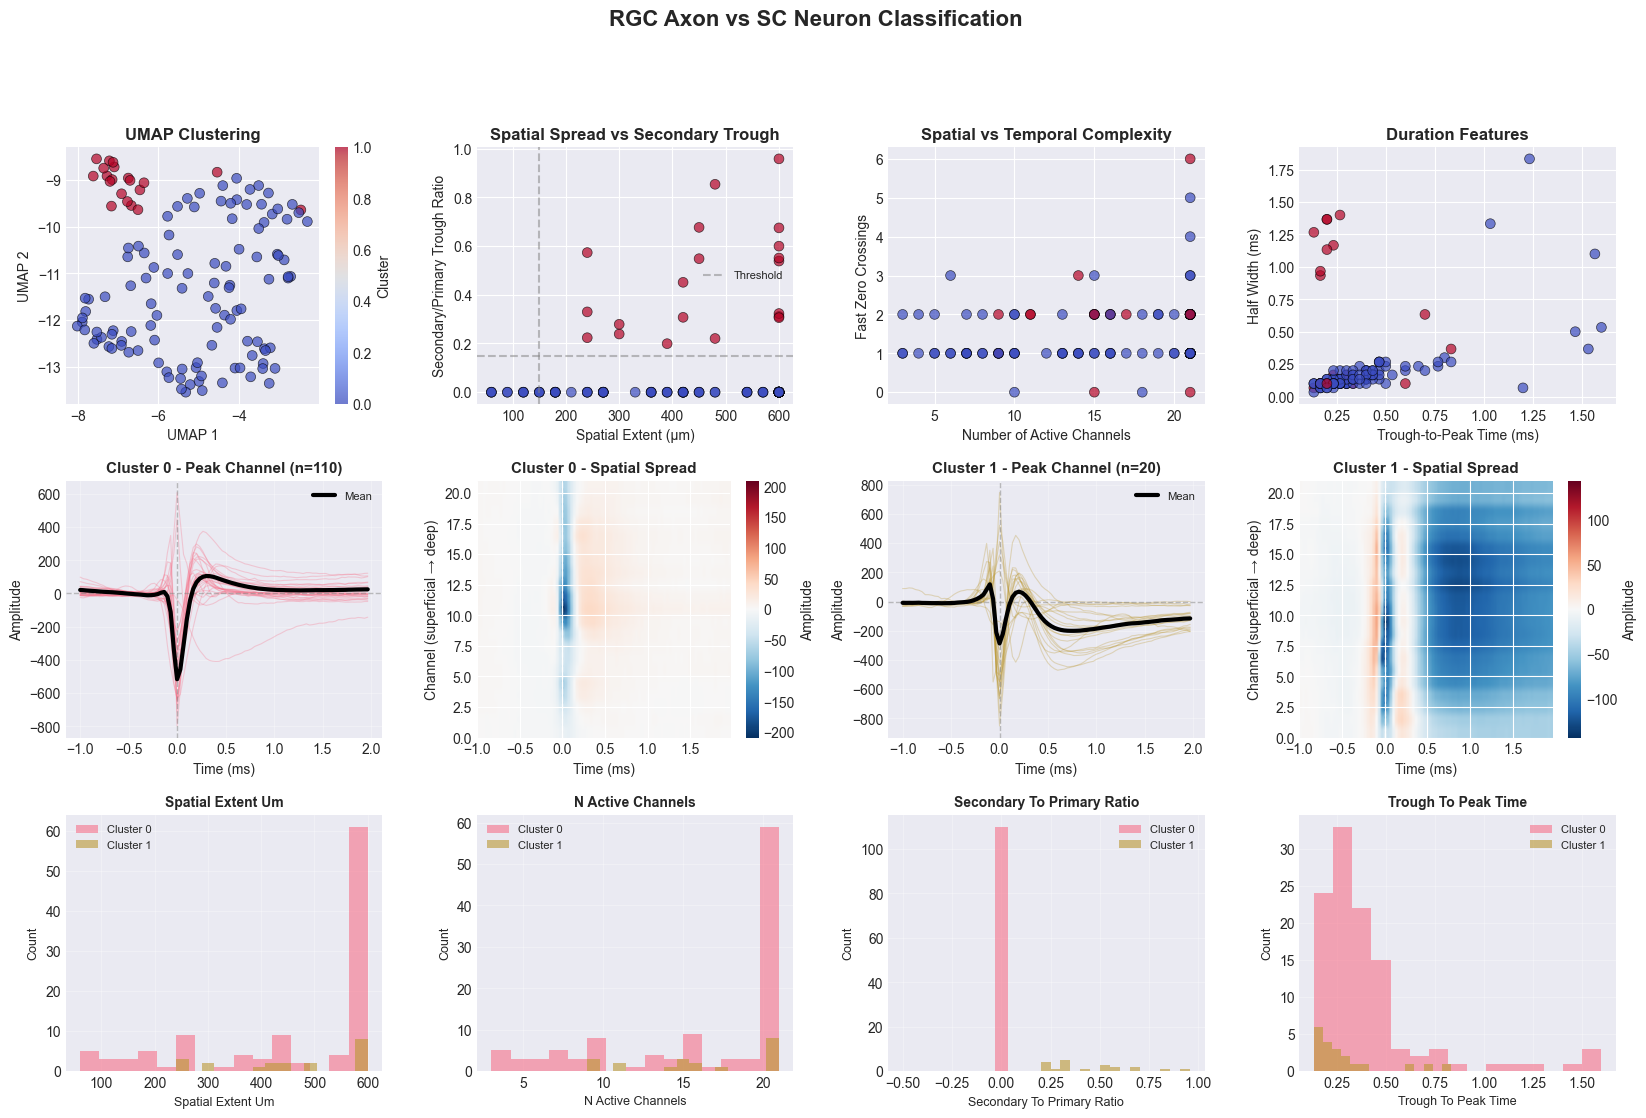

In [ ]:
# ==============================================================================
# 6. COMPREHENSIVE VISUALIZATION
# ==============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# --- Row 1: Clustering results ---
# UMAP
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax1.set_xlabel('UMAP 1', fontsize=10)
ax1.set_ylabel('UMAP 2', fontsize=10)
ax1.set_title('UMAP Clustering', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Spatial extent vs secondary trough (KEY DISCRIMINATOR)
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(features_df['spatial_extent_um'], features_df['secondary_to_primary_ratio'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax2.set_xlabel('Spatial Extent (μm)', fontsize=10)
ax2.set_ylabel('Secondary/Primary Trough Ratio', fontsize=10)
ax2.set_title('Spatial Spread vs Secondary Trough', fontsize=12, fontweight='bold')
ax2.axhline(0.15, color='gray', linestyle='--', alpha=0.5, label='Threshold')
ax2.axvline(150, color='gray', linestyle='--', alpha=0.5)
ax2.legend(fontsize=8)

# Number of active channels vs fast components
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(features_df['n_active_channels'], features_df['fast_zero_crossings'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax3.set_xlabel('Number of Active Channels', fontsize=10)
ax3.set_ylabel('Fast Zero Crossings', fontsize=10)
ax3.set_title('Spatial vs Temporal Complexity', fontsize=12, fontweight='bold')

# Duration features
ax4 = fig.add_subplot(gs[0, 3])
scatter = ax4.scatter(features_df['trough_to_peak_time'], features_df['half_width'], 
                      c=labels, cmap='coolwarm', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
ax4.set_xlabel('Trough-to-Peak Time (ms)', fontsize=10)
ax4.set_ylabel('Half Width (ms)', fontsize=10)
ax4.set_title('Duration Features', fontsize=12, fontweight='bold')

# --- Row 2: Example waveforms from each cluster ---
for cluster_id in [0, 1]:
    cluster_units = np.where(labels == cluster_id)[0]
    
    # Single-channel waveforms
    ax = fig.add_subplot(gs[1, cluster_id*2])
    t_ms = (np.arange(nS) - sbefore) / sr * 1000
    
    for unit_idx in cluster_units[:30]:  # Plot up to 30
        wf = unit_data[unit_idx]['peak_waveform']
        ax.plot(t_ms, wf, alpha=0.3, color=f'C{cluster_id}', linewidth=0.8)
    
    mean_wf = np.mean([unit_data[i]['peak_waveform'] for i in cluster_units], axis=0)
    ax.plot(t_ms, mean_wf, color='black', linewidth=3, label='Mean', zorder=100)
    
    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f'Cluster {cluster_id} - Peak Channel (n={len(cluster_units)})', fontsize=11, fontweight='bold')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Multi-channel heatmap (spatial spread visualization)
    ax = fig.add_subplot(gs[1, cluster_id*2 + 1])
    
    # Average across cluster
    mean_multichan = np.mean([unit_data[i]['multichan_waveforms'] for i in cluster_units[:20]], axis=0)
    
    im = ax.imshow(mean_multichan, aspect='auto', cmap='RdBu_r', 
                   extent=[t_ms[0], t_ms[-1], 0, mean_multichan.shape[0]],
                   vmin=-np.max(np.abs(mean_multichan)), vmax=np.max(np.abs(mean_multichan)))
    ax.set_xlabel('Time (ms)', fontsize=10)
    ax.set_ylabel('Channel (superficial → deep)', fontsize=10)
    ax.set_title(f'Cluster {cluster_id} - Spatial Spread', fontsize=11, fontweight='bold')
    ax.axvline(0, color='white', linestyle='--', alpha=0.7, linewidth=1)
    plt.colorbar(im, ax=ax, label='Amplitude')

# --- Row 3: Feature distributions ---
feature_comparison = ['spatial_extent_um', 'n_active_channels', 
                      'secondary_to_primary_ratio', 'trough_to_peak_time']

for idx, feat in enumerate(feature_comparison):
    ax = fig.add_subplot(gs[2, idx])
    
    for cluster_id in [0, 1]:
        cluster_data = features_df[features_df['cluster_label'] == cluster_id][feat]
        ax.hist(cluster_data, alpha=0.6, label=f'Cluster {cluster_id}', bins=15, color=f'C{cluster_id}')
    
    ax.set_xlabel(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(f'{feat.replace("_", " ").title()}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('RGC Axon vs SC Neuron Classification', fontsize=16, fontweight='bold', y=0.995)
# plt.savefig('cell_type_classification_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# RGCs should have: larger spatial extent, more secondary trough, more active channels
cluster_stats = features_df.groupby('cluster_label')[
    ['spatial_extent_um', 'secondary_to_primary_ratio', 'n_active_channels']
].mean()

print("\n=== CLUSTER STATISTICS ===")
print(cluster_stats)

# Identify RGC cluster (higher spatial extent + secondary trough)
rgc_score = (
    cluster_stats['spatial_extent_um'] + 
    cluster_stats['secondary_to_primary_ratio'] * 100 +
    cluster_stats['n_active_channels'] * 10
)
rgc_cluster = rgc_score.idxmax()
sc_cluster = 1 - rgc_cluster

features_df['cell_type'] = features_df['cluster_label'].map({
    rgc_cluster: 'RGC',
    sc_cluster: 'SC'
})

print(f"\n=== CELL TYPE ASSIGNMENT ===")
print(f"RGC Cluster: {rgc_cluster}")
print(f"SC Cluster: {sc_cluster}")
print(f"\nCell type counts:")
print(features_df['cell_type'].value_counts())




=== CLUSTER STATISTICS ===
               spatial_extent_um  secondary_to_primary_ratio  \
cluster_label                                                  
0                     464.181824                    0.000000   
1                     460.500000                    0.458115   

               n_active_channels  
cluster_label                     
0                      16.327273  
1                      16.250000  

=== CELL TYPE ASSIGNMENT ===
RGC Cluster: 1
SC Cluster: 0

Cell type counts:
cell_type
SC     110
RGC     20
Name: count, dtype: int64


In [ ]:
# Save results
features_df.to_csv('unit_classification_results.csv', index=False)
savemat('unit_classification_results.mat', {
    'features': features_df.to_dict('list'),
    'cluster_labels': labels,
    'cell_types': features_df['cell_type'].values
})

print("\n✓ Results saved!")


=== RAW FEATURE STATISTICS ===
       spatial_extent_um  spatial_spread_weighted  n_active_channels  \
count         130.000000               130.000000         130.000000   
mean          463.615387               112.684384          16.315385   
std           172.685150                20.785337           5.785621   
min            60.000000                73.532167           3.000000   
25%           360.000000                97.586173          12.250000   
50%           600.000000               109.729810          20.000000   
75%           600.000000               123.481628          21.000000   
max           600.000000               193.221485          21.000000   

       half_max_spread_um  has_secondary_trough  secondary_to_primary_ratio  \
count          130.000000            130.000000                  130.000000   
mean           352.153846              0.153846                    0.070479   
std            194.513843              0.362197                    0.186147   
min

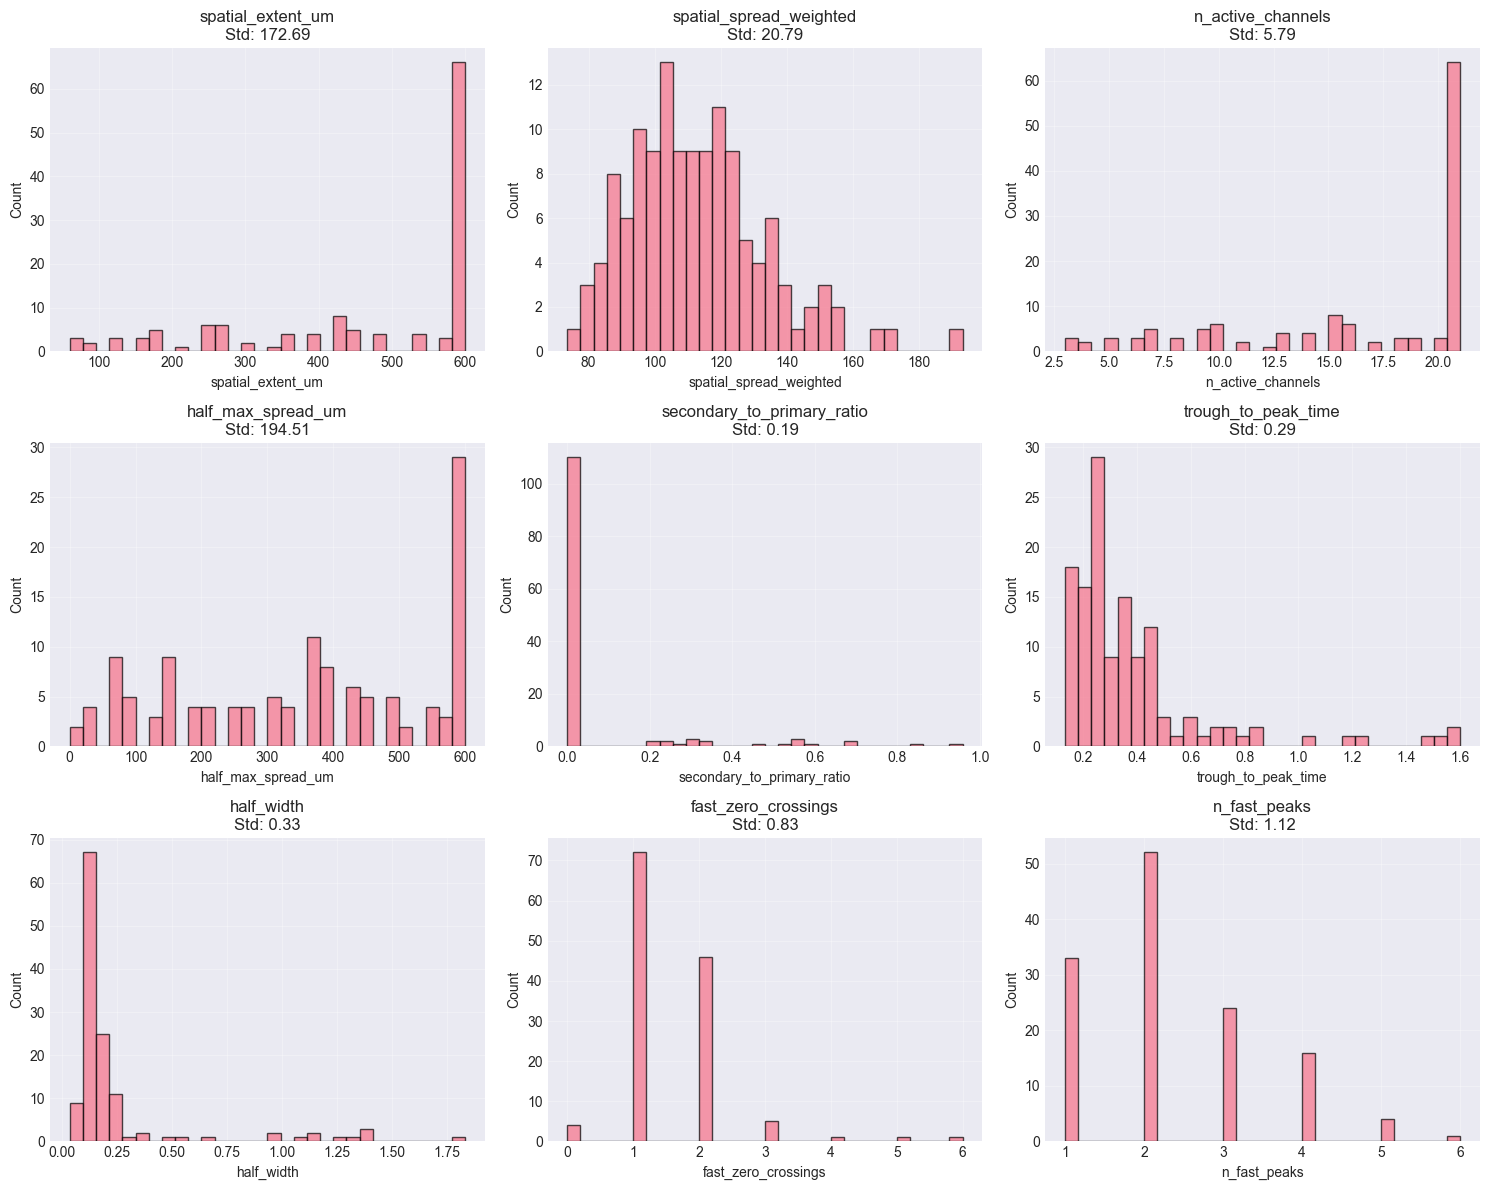

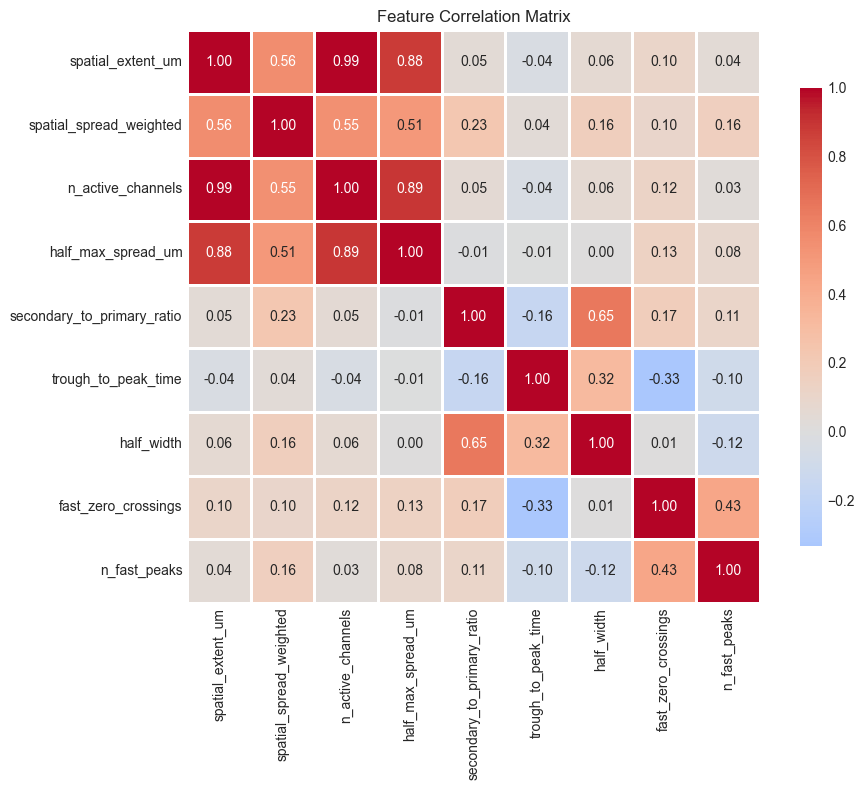

In [ ]:
##################################################
# Diagnostics

# ==============================================================================
# DIAGNOSTIC: Examine feature distributions
# ==============================================================================

# Check all features
print("\n=== RAW FEATURE STATISTICS ===")
print(features_df[['spatial_extent_um', 'spatial_spread_weighted', 'n_active_channels',
                   'half_max_spread_um', 'has_secondary_trough', 'secondary_to_primary_ratio',
                   'trough_to_peak_time', 'half_width', 'fast_zero_crossings']].describe())

# Check for constant features
print("\n=== FEATURE VARIANCE ===")
print(features_df[['spatial_extent_um', 'spatial_spread_weighted', 'n_active_channels',
                   'half_max_spread_um']].std())

# Visualize feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
feature_cols = ['spatial_extent_um', 'spatial_spread_weighted', 'n_active_channels',
                'half_max_spread_um', 'secondary_to_primary_ratio', 'trough_to_peak_time',
                'half_width', 'fast_zero_crossings', 'n_fast_peaks']

for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 3, idx % 3]
    ax.hist(features_df[feat].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.set_title(f'{feat}\nStd: {features_df[feat].std():.2f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('feature_distributions_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()

# Check correlation between features
import seaborn as sns
plt.figure(figsize=(10, 8))
corr_matrix = features_df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
# plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()